In [ ]:
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
load_dotenv()

model = ChatGoogleGenerativeAI(model="gemini-2.0-flash")

True

In [3]:
from typing import Annotated # annotated는 타입 힌트를 사용할 때 사용하는 함수
from typing_extensions import TypedDict # TypedDict는 딕셔너리 타입을 정의할 때 사용하는 함수

from langgraph.graph.message import add_messages

# 상태 정의
class State(TypedDict):	
    messages: Annotated[list[str], add_messages]

In [4]:
from langgraph.graph import StateGraph

# 그래프 구성
graph_builder = StateGraph(State)

In [ ]:
from langchain_core.tools import tool
from datetime import datetime
import pytz
from langchain_community.tools import DuckDuckGoSearchResults
from langchain_community.utilities import DuckDuckGoSearchAPIWrapper

import bs4
from langchain_community.document_loaders import WebBaseLoader

# 도구 함수 정의
@tool
def get_current_time(timezone: str, location: str) -> str:
    """현재 시각을 반환하는 함수."""
    try:
        tz = pytz.timezone(timezone)
        now = datetime.now(tz).strftime("%Y-%m-%d %H:%M:%S")
        result = f'{timezone} ({location}) 현재시각 {now}'
        # print(result)
        return result
    except pytz.UnknownTimeZoneError:
        return f"알 수 없는 타임존: {timezone}"
    
@tool
def get_web_search(query: str, search_period: str='m') -> str:
    """
    웹 검색을 수행하는 함수.
    """
    wrapper = DuckDuckGoSearchAPIWrapper(
        # region="kr-kr", 
        time=search_period
    )

    print('\n-------- WEB SEARCH --------')
    print(query)
    print(search_period)

    search = DuckDuckGoSearchResults(
        api_wrapper=wrapper,
        # source="news",
        results_separator=';\n'
    )

    searched = search.invoke(query)
    
    for i, result in enumerate(searched.split(';\n')):
        print(f'{i+1}. {result}')
    
    return searched

# 도구 바인딩
tools = [get_current_time, get_web_search]

USER_AGENT environment variable not set, consider setting it to identify your requests.


In [6]:
tools[0].invoke({"timezone": "Asia/Seoul", "location": "부산"})

'Asia/Seoul (부산) 현재시각 2025-09-16 14:08:02'

In [7]:
query = "2025년 KT 소액결제 사건의 원인은?"

In [8]:
tools[1].invoke({"query": query, "search_period": "m"})


-------- WEB SEARCH --------
2025년 KT 소액결제 사건의 원인은?
m
1. snippet: 20시간 전 — 주요 원인. 불법 초소형 기지국의 KT 통신망 접속 (추정)[2] ; 피해 규모. 무단 소액결제 278건, 약 1억 7,000만원[3] 가입자 5,561명의 IMSI 유출 가능성 ; 발생 지역., title: KT 고객 무단 소액결제 침해 사고, link: https://namu.wiki/w/KT+고객+무단+소액결제+침해+사고
2. snippet: 5일 전 — KT 소액결제 피해의 핵심 원인이 불법 초소형 기지국인 것으로 드러났다 . 또한, 피해자 단말이 불법 초소형 기지국에 위치 정보를 등록하는 과정에서 국제이동가입자식별 ..., title: KT 소액결제 피해, 원인은 '불법 초소형 기지국'…IMSI 유출 ..., link: https://byline.network/2025/09/11-553/
3. snippet: 6일 전 — 경기 광명 등에서 잇따라 벌어진 ' KT 소액결제 피해' 사건의 원인 이 '불법 초소형 기지국'일 가능성이 처음으로 제기됐습니다. 혹시 모를 추가 피해를 막기 위해 KT 는 ..., title: “'KT 소액결제 피해' 불법 기지국 원인 가능성…현재 전면 차단”, link: https://news.kbs.co.kr/news/view.do?ncd=8353982&req_by=aipick
4. snippet: 4일 전 — KT 가입자 휴대전화에서 본인 동의 없이 모바일상품권 구매나 교통카드 충전이 이뤄진 소액결제 피해 사건은 8월 27일부터 31일 사이 경기 광명 지역에서 처음 발생했다., title: KT 소액결제 해킹, 펨토셀 수법으로 드러나…개인정보 유출 ..., link: https://www.dailysecu.com/news/articleView.html?idxno=200329


"snippet: 20시간 전 — 주요 원인. 불법 초소형 기지국의 KT 통신망 접속 (추정)[2] ; 피해 규모. 무단 소액결제 278건, 약 1억 7,000만원[3] 가입자 5,561명의 IMSI 유출 가능성 ; 발생 지역., title: KT 고객 무단 소액결제 침해 사고, link: https://namu.wiki/w/KT+고객+무단+소액결제+침해+사고;\nsnippet: 5일 전 — KT 소액결제 피해의 핵심 원인이 불법 초소형 기지국인 것으로 드러났다 . 또한, 피해자 단말이 불법 초소형 기지국에 위치 정보를 등록하는 과정에서 국제이동가입자식별 ..., title: KT 소액결제 피해, 원인은 '불법 초소형 기지국'…IMSI 유출 ..., link: https://byline.network/2025/09/11-553/;\nsnippet: 6일 전 — 경기 광명 등에서 잇따라 벌어진 ' KT 소액결제 피해' 사건의 원인 이 '불법 초소형 기지국'일 가능성이 처음으로 제기됐습니다. 혹시 모를 추가 피해를 막기 위해 KT 는 ..., title: “'KT 소액결제 피해' 불법 기지국 원인 가능성…현재 전면 차단”, link: https://news.kbs.co.kr/news/view.do?ncd=8353982&req_by=aipick;\nsnippet: 4일 전 — KT 가입자 휴대전화에서 본인 동의 없이 모바일상품권 구매나 교통카드 충전이 이뤄진 소액결제 피해 사건은 8월 27일부터 31일 사이 경기 광명 지역에서 처음 발생했다., title: KT 소액결제 해킹, 펨토셀 수법으로 드러나…개인정보 유출 ..., link: https://www.dailysecu.com/news/articleView.html?idxno=200329"

In [9]:
for tool in tools:
    print(tool.name, tool)

get_current_time name='get_current_time' description='현재 시각을 반환하는 함수.' args_schema=<class 'langchain_core.utils.pydantic.get_current_time'> func=<function get_current_time at 0x000002267943F240>
get_web_search name='get_web_search' description='웹 검색을 수행하는 함수.\n\nArgs:\n    query (str): 검색어\n    search_period (str): 검색 기간 (e.g., "w" for past week (default), "m" for past month, "y" for past year, "d" for past day)\n\nReturns:\n    str: 검색 결과' args_schema=<class 'langchain_core.utils.pydantic.get_web_search'> func=<function get_web_search at 0x0000022679757E20>


In [10]:
model_with_tools = model.bind_tools(tools) # GPT 언어모델에 도구 연결

def generate(state: State):
    return {"messages": model_with_tools.invoke(state["messages"])}

graph_builder.add_node("generate", generate)

In [11]:
import json
from langchain_core.messages import ToolMessage

class BasicToolNode:
    """
    도구를 실행하는 노드 클래스입니다. 마지막 AIMessage에서 요청된 도구를 실행합니다.
    """

    def __init__(self, tools: list) -> None:
        self.tools_by_name = {tool.name: tool for tool in tools}

    def __call__(self, inputs: dict):
        if messages := inputs.get("messages", []):
            # inputs에 messages가 있으면 messages를 가져오고 없으면 빈 리스트를 가져옵니다.
            message = messages[-1]
        else:
            raise ValueError("No message found in input")
        outputs = []
        for tool_call in message.tool_calls:
            tool_result = self.tools_by_name[tool_call["name"]].invoke(
                tool_call["args"]
            )
            outputs.append(
                ToolMessage(
                    content=json.dumps(tool_result),
                    name=tool_call["name"],
                    tool_call_id=tool_call["id"],
                )
            )
        return {"messages": messages + outputs}

In [12]:
tool_node = BasicToolNode(tools=tools)
graph_builder.add_node("tools", tool_node)

In [ ]:
from langgraph.graph import StateGraph, START, END

def route_tools(state: State):
    """
    마지막 메시지에 도구 호출이 있는 경우 ToolNode로 라우팅하고,
    그렇지 않은 경우 END로 라우팅하기 위해 conditional_edge에서 사용합니다.
    """
    if isinstance(state, list):
        ai_message = state[-1]
    elif messages := state.get("messages", []):
        ai_message = messages[-1]
    else:
        raise ValueError(f"tool_edge 입력 상태에서 메시지를 찾을 수 없습니다: {state}")
        
    if hasattr(ai_message, "tool_calls") and len(ai_message.tool_calls) > 0:
        return "tools"
    return END

In [14]:
graph_builder.add_edge(START, "generate")

graph_builder.add_conditional_edges(
    "generate",
    route_tools,
    {"tools": "tools", END: END},
)
# 도구가 호출될 때마다 다음 단계를 결정하기 위해 챗봇으로 돌아갑니다.
graph_builder.add_edge("tools", "generate")

In [15]:
graph = graph_builder.compile()

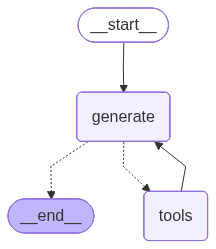

In [16]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [22]:
from langchain_core.messages import AIMessageChunk, HumanMessage

inputs = [HumanMessage(content="지금 부산 몇시야?")]

gathered = None

for msg, metadata in graph.stream({"messages": inputs}, stream_mode="messages"):
    if isinstance(msg, AIMessageChunk):
        print(msg.content, end='')

        if gathered is None:
            gathered = msg
        else:
            gathered = gathered + msg

지금 부산은 2025년 9월 16일 14시 38분 18초입니다.


In [23]:
gathered

AIMessageChunk(content='지금 부산은 2025년 9월 16일 14시 38분 18초입니다.\n', additional_kwargs={'function_call': {'name': 'get_current_time', 'arguments': '{"location": "\\ubd80\\uc0b0", "timezone": "Asia/Seoul"}'}}, response_metadata={'finish_reason': 'STOPSTOP', 'model_name': 'gemini-2.0-flashgemini-2.0-flash', 'safety_ratings': []}, id='run--52e6cf85-7058-4985-84f6-2c7cc101f180', tool_calls=[{'name': 'get_current_time', 'args': {'location': '부산', 'timezone': 'Asia/Seoul'}, 'id': '020c3366-e86e-404e-818e-a7d9370961f4', 'type': 'tool_call'}], usage_metadata={'input_tokens': 284, 'output_tokens': 45, 'total_tokens': 387, 'input_token_details': {'cache_read': 0}}, tool_call_chunks=[{'name': 'get_current_time', 'args': '{"location": "\\ubd80\\uc0b0", "timezone": "Asia/Seoul"}', 'id': '020c3366-e86e-404e-818e-a7d9370961f4', 'index': None, 'type': 'tool_call_chunk'}])

In [ ]:
from langchain_core.messages import AIMessageChunk, SystemMessage

inputs = [
    SystemMessage(content=f"""
        너는 신문기자이다. 
        최근 {query}에 대해 비판하는 심층 분석 기사를 쓰려고 한다.
    """),
    HumanMessage(content="""
        - 최근 어떤 이슈가 있는지 검색하고, 사람들이 제일 관심있어 할만한 주제를 선정하고, 왜 선정했는지 말해줘. 
        - 그 내용으로 원고를 작성하기 위한 목차를 만들고, 목차 내용을 채우기 위해 추가로 검색할 내용을 리스트로 정리해봐. 
        - 검색할 리스트를 토대로 재검색을 한다. 
        - 목차에 있는 내용을 작성하기 위해 더 검색이 필요한 정보가 있는지 확인하고, 있다면 추가로 검색해라.
        - 검색된 결과에 원하는 정보를 찾지 못했다면 다른 검색어로 재검색해도 좋다. 
        
        더 이상 검색할 내용이 없다면, 조선일보 신문 기사 형식으로 최종 기사를 작성하라.
        제목, 부제, 리드문, 본문 의 구성으로 작성하라. 본문 내용은 심층 분석 기사에 맞게 구체적이고 깊이 있게 작성해야 한다.
    """)
]

gathered = None

for msg, metadata in graph.stream({"messages": inputs}, stream_mode="messages"):
    if isinstance(msg, AIMessageChunk):
        # print(msg.content, end='')

        if gathered is None:
            gathered = msg
        else:
            gathered = gathered + msg

알겠습니다. 2025년 KT 소액결제 사건에 대한 심층 분석 기사를 작성하기 위해 다음과 같은 단계를 따르겠습니다.

**1. 최신 이슈 검색 및 주제 선정:**

먼저 최근 이슈를 검색하여 사람들이 가장 관심을 가질 만한 주제를 선정하고, 그 이유를 설명하겠습니다.


-------- WEB SEARCH --------
KT 소액결제 2025 사건
m
1. snippet: 5 days ago · 과기정통부는 10일 정부서울청사에서 현안 브리핑을 열어 KT 무단 소액결제 피해 건수가 이날 기준 278건, 피해 금액은 1억 7000여만원에 이르는 ..., title: KT 소액결제 피해 1억 7000만원… 개보위, KT ·LGU+ 정보 ... - 서울 신문, link: https://www.seoul.co.kr/news/economy/industry/2025/09/11/20250911002003
2. snippet: 6 days ago · KT 무단 소액결제 사건 실체가 조금씩 수면 위로 떠오르는 가운데 KT가 사건의 특수성을 감지한 경찰의 고지 이후에도 수일간 적극적인 대처 없이 뭉갠 것으로 드러나 충격을 주고 있다. …, title: KT , 소액결제 사건 경찰 통보 뒤 나흘 뭉갰다 | 연합뉴스, link: https://www.yna.co.kr/view/AKR20250910061000017
3. snippet: Sep 4, 2025 · KT 공식 홈페이지에서 다양한 상품과 서비스를 이용하시는 고객님께 특별한 혜택과 맞춤형 서비스를 제공합니다. 최신 핸드폰을 포함한 여러 제품을 구매하고, 다양한 이벤트에도 …, title: KT, link: https://www.kt.com/
4. snippet: 6 days ago · 불법 기지국 역할한듯 viewer 9일 한 시민이 서울 kt 판매점 앞을 지나고 있다. 연합뉴스 무단 소액결제 사건과 관련해 KT 가입자에 대한 공격 경로로 초소형 기지국이 지목된 가운데 …, title: [단독] KT 무단결제 통로 지목된 

In [29]:
gathered

AIMessageChunk(content='알겠습니다. 2025년 KT 소액결제 사건에 대한 심층 분석 기사를 작성하기 위해 다음과 같은 단계를 따르겠습니다.\n\n**1. 최신 이슈 검색 및 주제 선정:**\n\n먼저 최근 이슈를 검색하여 사람들이 가장 관심을 가질 만한 주제를 선정하고, 그 이유를 설명하겠습니다.\n\n최근 KT 소액결제 사건이 큰 이슈이며, 특히 \'KT, 소액결제 사건 경찰 통보 뒤 나흘 뭉갰다\'라는 내용이 사람들의 분노를 일으키고 있습니다. 사건 발생 후 KT의 초기 대응이 미흡했다는 점이 중요하게 다뤄질 만하다고 판단했습니다. 피해 규모가 1억 7천만원에 달한다는 점, 그리고 공격 경로로 초소형 기지국이 지목되었다는 점 또한 주요 관심사입니다.\n\n**기사 목차**\n\n1.  **머리말**: KT 소액결제 사건 발생과 피해 규모 요약, 늑장 대응 비판\n2.  **사건의 전말**:\n    *   2025년 KT 소액결제 사건의 구체적인 발생 경위\n    *   피해 규모 및 피해자 현황 상세 분석\n    *   초소형 기지국을 이용한 공격 경로 심층 분석\n3.  **KT의 늑장 대응**:\n    *   경찰 신고 접수 후 KT의 초기 대응 과정 상세 재구성\n    *   늑장 대응의 원인 분석: 내부 보고 지연, 상황 판단 미흡 등\n    *   늑장 대응으로 인한 피해 확대 사례\n4.  **피해자 구제 및 보상**:\n    *   KT의 피해자 구제 및 보상 계획 발표 내용 분석\n    *   실질적인 피해 보상 진행 상황 및 문제점 지적\n    *   피해자들이 요구하는 보상 수준 및 추가 요구 사항\n5.  **재발 방지 대책**:\n    *   KT가 발표한 재발 방지 대책의 실효성 검토\n    *   유사 사건 재발 방지를 위한 정부 및 통신 업계의 노력 촉구\n    *   소비자 보호를 위한 제도 개선 방안 제시\n6.  **결론**: KT 소액결제 사건의 교훈, 소비자 신뢰 회복을 위한 과제

In [28]:
print(gathered.content)

알겠습니다. 2025년 KT 소액결제 사건에 대한 심층 분석 기사를 작성하기 위해 다음과 같은 단계를 따르겠습니다.

**1. 최신 이슈 검색 및 주제 선정:**

먼저 최근 이슈를 검색하여 사람들이 가장 관심을 가질 만한 주제를 선정하고, 그 이유를 설명하겠습니다.

최근 KT 소액결제 사건이 큰 이슈이며, 특히 'KT, 소액결제 사건 경찰 통보 뒤 나흘 뭉갰다'라는 내용이 사람들의 분노를 일으키고 있습니다. 사건 발생 후 KT의 초기 대응이 미흡했다는 점이 중요하게 다뤄질 만하다고 판단했습니다. 피해 규모가 1억 7천만원에 달한다는 점, 그리고 공격 경로로 초소형 기지국이 지목되었다는 점 또한 주요 관심사입니다.

**기사 목차**

1.  **머리말**: KT 소액결제 사건 발생과 피해 규모 요약, 늑장 대응 비판
2.  **사건의 전말**:
    *   2025년 KT 소액결제 사건의 구체적인 발생 경위
    *   피해 규모 및 피해자 현황 상세 분석
    *   초소형 기지국을 이용한 공격 경로 심층 분석
3.  **KT의 늑장 대응**:
    *   경찰 신고 접수 후 KT의 초기 대응 과정 상세 재구성
    *   늑장 대응의 원인 분석: 내부 보고 지연, 상황 판단 미흡 등
    *   늑장 대응으로 인한 피해 확대 사례
4.  **피해자 구제 및 보상**:
    *   KT의 피해자 구제 및 보상 계획 발표 내용 분석
    *   실질적인 피해 보상 진행 상황 및 문제점 지적
    *   피해자들이 요구하는 보상 수준 및 추가 요구 사항
5.  **재발 방지 대책**:
    *   KT가 발표한 재발 방지 대책의 실효성 검토
    *   유사 사건 재발 방지를 위한 정부 및 통신 업계의 노력 촉구
    *   소비자 보호를 위한 제도 개선 방안 제시
6.  **결론**: KT 소액결제 사건의 교훈, 소비자 신뢰 회복을 위한 과제 제시

**추가 검색 내용 리스트**

*   KT 소액결제 사건 관련 피해자 인터뷰
*   